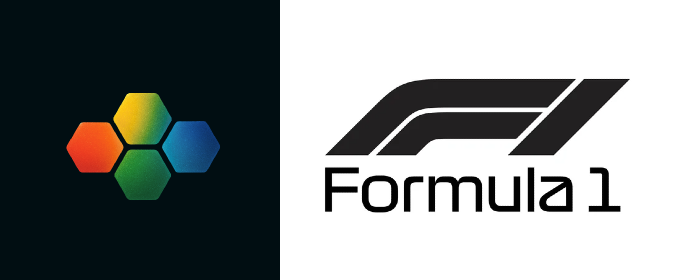

---

# **This is a clean environment where you'll learn how to train RL models using PPO proximal policy optimisation algorithmn to train your FORMULA ONE racer**  <br>



*   CELL 1 : Installs the modules <br>
*   CELL 2 : defined the environment where the RL model will train itself and the reward functions that restricts it and trains it better<br>
*   CELL 3 : To train the final model <br>
*   CELL 4 : To evaluate the model based on all the parameters and compares all your models and gives you a list of all models that u trained and also updates live ranking of urself in the competition<br>
*   CELL 5 : If you want to see your model racing in the track that u trained run this cell <br>
*   FINAL CELL : please upload the .zip of the model that was downloaded! for us to see what u did and fill feedback in it <br>


***Built with love :3 - by the students just like you*** <br>
 ***Microsoft Innovations Club - AIML Departnment - PreTechnoVIT 2026***

# **Cell 1: Dependencies & Headless Setup**

In [ ]:
# just run this , it will install the required modules in the colab
!pip install gymnasium stable-baselines3 imageio[ffmpeg] pandas tabulate -q
import os
os.environ["SDL_VIDEODRIVER"] = "dummy"
print("Dependencies installed and headless display configured successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 4.6 MB/s eta 0:00:00
Dependencies installed and headless display configured successfully!


<br>

### Understanding the Environment
Here's a quick rundown of the environment code below. We're using `gymnasium` to set up the track for our agent (the car).

- **Observation Space**: This defines what the car can 'see' at any given moment. We give it 5 LiDAR distance sensors, its current speed, and its heading error.
- **Action Space**: This is what the car can control. It outputs continuous values for steering and throttle/braking.
- **Step Function**: The main simulation loop. The agent takes an action, and the environment updates the physics, returning the new state and the reward.
- **Reward Function**: This is the most crucial part. The car gets points for moving forward and staying fast, and loses a lot of points for hitting a wall. The whole goal of the agent is just to maximize this number.

# Cell 2: The Core Racetrack Environment ( dont alter the code , just read it and run the cell )

---

This cell defines the stadium track, LiDAR raycasting, vehicle kinematics, and off-screen rendering. & reward functions

---


In [ ]:
# Cell 2: Multi-Track F1 Environment (Generalization Testing)
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import math
import pygame

# THIS IS THE MAIN CODE StadiumF1Env(gym.Env) THAT DEFINES YOUR REWARD FUNCTIONS , PLEASE LOOK AT THE CODE BUT DONT ALTER THEM OR IT WONT WORK

class StadiumF1Env(gym.Env):
    metadata = {"render_modes": ["rgb_array", "human"], "render_fps": 30}
    def __init__(self, render_mode="rgb_array", reward_config=None, track_type="oval"):
        super().__init__()
        self.render_mode = render_mode
        self.track_type = track_type
        self.reward_config = reward_config or {
            "w_time": -0.1, "w_progress": 15.0, "w_speed": 0.5, "w_crash": -100.0, "w_lap": 1000.0
        }
        self.CAR_LENGTH, self.CAR_WIDTH, self.TRACK_WIDTH = 4.2, 2.0, 6.0
        self.MAX_SPEED, self.MAX_ACCEL, self.MAX_TURN, self.DT = 24.0, 10.0, 1.3, 0.1

        self.action_space = spaces.Box(low=np.array([-1.0, -0.7], dtype=np.float32), high=np.array([1.0, 1.0], dtype=np.float32), dtype=np.float32)
        self.observation_space = spaces.Box(low=np.array([0.0]*5 + [0.0, -np.float32(np.pi)], dtype=np.float32), high=np.array([50.0]*5 + [self.MAX_SPEED, np.float32(np.pi)], dtype=np.float32), dtype=np.float32)

        self._build_circuit()
        self.surface = None
        self.reset()

# this function builds the racetrack
    def _build_circuit(self):
        self.waypoints = []

        if self.track_type == "oval":
            R, L = 22.0, 35.0
            for x in np.linspace(L, -L, 12, endpoint=False): self.waypoints.append((float(x), -R))
            for a in np.linspace(-math.pi/2, -3*math.pi/2, 16, endpoint=False): self.waypoints.append((float(-L + R * math.cos(a)), float(R * math.sin(a))))
            for x in np.linspace(-L, L, 12, endpoint=False): self.waypoints.append((float(x), R))
            for a in np.linspace(math.pi/2, -math.pi/2, 16, endpoint=False): self.waypoints.append((float(L + R * math.cos(a)), float(R * math.sin(a))))

        elif self.track_type == "square":
            # Street Circuit (Rounded Rectangle) - Fixes 90-degree corner spikes
            L, R = 20.0, 10.0
            for x in np.linspace(L, -L, 8, endpoint=False): self.waypoints.append((float(x), -L - R))
            for a in np.linspace(-math.pi/2, -math.pi, 8, endpoint=False): self.waypoints.append((float(-L + R * math.cos(a)), float(-L + R * math.sin(a))))
            for y in np.linspace(-L, L, 8, endpoint=False): self.waypoints.append((-L - R, float(y)))
            for a in np.linspace(-math.pi, -3*math.pi/2, 8, endpoint=False): self.waypoints.append((float(-L + R * math.cos(a)), float(L + R * math.sin(a))))
            for x in np.linspace(-L, L, 8, endpoint=False): self.waypoints.append((float(x), L + R))
            for a in np.linspace(math.pi/2, 0, 8, endpoint=False): self.waypoints.append((float(L + R * math.cos(a)), float(L + R * math.sin(a))))
            for y in np.linspace(L, -L, 8, endpoint=False): self.waypoints.append((L + R, float(y)))
            for a in np.linspace(0, -math.pi/2, 8, endpoint=False): self.waypoints.append((float(L + R * math.cos(a)), float(-L + R * math.sin(a))))

        elif self.track_type == "snake":
            # Continuous Tri-Oval S-Curve (Perfectly smooth and closed)
            for a in np.linspace(0, -2*math.pi, 45, endpoint=False):
                r = 24.0 + 8.0 * math.sin(3 * a) # 3-lobed parametric curve
                self.waypoints.append((float(r * math.cos(a)), float(r * math.sin(a))))

        self.waypoints = np.array(self.waypoints, dtype=np.float32)
        self.total_waypoints = len(self.waypoints)

        half_w = self.TRACK_WIDTH / 2.0
        self.inner_walls, self.outer_walls = [], []

        # Central Difference Normal Math (Prevents all polygon cross-overs)
        for i in range(self.total_waypoints):
            p_prev = self.waypoints[i - 1]
            p_curr = self.waypoints[i]
            p_next = self.waypoints[(i + 1) % self.total_waypoints]

            tangent = p_next - p_prev
            tangent /= (np.linalg.norm(tangent) + 1e-6)
            normal = np.array([-tangent[1], tangent[0]], dtype=np.float32)

            self.outer_walls.append(p_curr + normal * half_w)
            self.inner_walls.append(p_curr - normal * half_w)

        self.inner_walls, self.outer_walls = np.array(self.inner_walls, dtype=np.float32), np.array(self.outer_walls, dtype=np.float32)

# this function resets the car to initial position if needed (not needed)
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.x, self.y = self.waypoints[0][0], self.waypoints[0][1]
        dx, dy = self.waypoints[1][0] - self.x, self.waypoints[1][1] - self.y
        self.theta = math.atan2(dy, dx)
        self.speed, self.target_wp_idx, self.waypoints_passed, self.steps, self.max_speed = 0.0, 1, 0, 0, 0.0
        return self._get_obs(), {}

# this defined the step the model will take each frame of the run

    def step(self, action):
        self.steps += 1
        steer_input, accel_input = float(action[0]), np.clip(float(action[1]), -0.7, 1.0)

        turn_rate = steer_input * self.MAX_TURN * (1.0 - (self.speed / self.MAX_SPEED) * 0.45)
        self.speed = np.clip(self.speed + (accel_input * self.MAX_ACCEL * self.DT), 0.0, self.MAX_SPEED)
        if self.speed > 0.1: self.theta += turn_rate * self.DT

        self.x += self.speed * math.cos(self.theta) * self.DT
        self.y += self.speed * math.sin(self.theta) * self.DT
        self.max_speed = max(self.max_speed, self.speed)

        target_wp = self.waypoints[self.target_wp_idx]
        passed_wp = False
        if math.hypot(target_wp[0] - self.x, target_wp[1] - self.y) < (self.TRACK_WIDTH * 1.2):
            passed_wp = True
            self.target_wp_idx = (self.target_wp_idx + 1) % self.total_waypoints
            self.waypoints_passed += 1

        lidar_readings, _ = self._compute_lidar()
        crashed = any(d < 0.8 for d in lidar_readings)
        lap_complete = self.waypoints_passed >= self.total_waypoints
        terminated, truncated = crashed or lap_complete, self.steps >= 1200

        cfg = self.reward_config
        reward = cfg["w_time"] + ((self.speed / self.MAX_SPEED) * cfg["w_speed"])
        if passed_wp: reward += cfg["w_progress"]
        if crashed: reward += cfg["w_crash"]
        elif lap_complete: reward += cfg["w_lap"]

        info = {"crashed": crashed, "lap_complete": lap_complete, "steps": self.steps, "max_speed": self.max_speed}
        return self._get_obs(), reward, terminated, truncated, info

    def _compute_lidar(self):
        lidar_dist = []
        for a in [-math.pi/2, -math.pi/4, 0.0, math.pi/4, math.pi/2]:
            ray_theta = self.theta + a
            dx, dy = math.cos(ray_theta), math.sin(ray_theta)
            min_dist = 50.0
            for walls in [self.inner_walls, self.outer_walls]:
                for i in range(len(walls)):
                    p1, p2 = walls[i], walls[(i + 1) % len(walls)]
                    x1, y1, x2, y2 = p1[0]-self.x, p1[1]-self.y, p2[0]-self.x, p2[1]-self.y
                    det = dx * (y2 - y1) - dy * (x2 - x1)
                    if abs(det) > 1e-5:
                        t, u = (x1*(y2 - y1) - y1*(x2 - x1))/det, -(dx*y1 - dy*x1)/det
                        if t > 0 and 0.0 <= u <= 1.0 and t < min_dist: min_dist = t
            lidar_dist.append(min_dist)
        heading_error = (math.atan2(self.waypoints[self.target_wp_idx][1] - self.y, self.waypoints[self.target_wp_idx][0] - self.x) - self.theta + math.pi) % (2*math.pi) - math.pi
        return lidar_dist, heading_error

    def _get_obs(self):
        lidar_dist, heading_error = self._compute_lidar()
        return np.array(lidar_dist + [self.speed, heading_error], dtype=np.float32)

    def render(self):
        SCALE, OFFSET, WIDTH, HEIGHT = 7.5, (400, 270), 800, 540
        if self.surface is None:
            pygame.init()
            self.surface = pygame.Surface((WIDTH, HEIGHT))
        self.surface.fill((45, 120, 50))

        for i in range(self.total_waypoints):
            nxt = (i + 1) % self.total_waypoints
            pts = [(int(w[0]*SCALE + OFFSET[0]), int(w[1]*SCALE + OFFSET[1])) for w in [self.outer_walls[i], self.outer_walls[nxt], self.inner_walls[nxt], self.inner_walls[i]]]
            pygame.draw.polygon(self.surface, (40, 42, 48), pts)
            curb_color = (230, 40, 40) if (i % 2 == 0) else (240, 240, 240)
            pygame.draw.line(self.surface, curb_color, pts[0], pts[1], 4)
            pygame.draw.line(self.surface, curb_color, pts[3], pts[2], 4)

        cx, cy, c_cos, c_sin = int(self.x * SCALE + OFFSET[0]), int(self.y * SCALE + OFFSET[1]), math.cos(self.theta), math.sin(self.theta)
        def lg(lx, ly): return (int(cx + (lx * c_cos - ly * c_sin) * (SCALE / 6.0)), int(cy + (lx * c_sin + ly * c_cos) * (SCALE / 6.0)))

        for tx, ty in [(-9, -7), (-9, 7), (9, -7), (9, 7)]: pygame.draw.polygon(self.surface, (15, 15, 15), [lg(tx-3, ty-2), lg(tx+3, ty-2), lg(tx+3, ty+2), lg(tx-3, ty+2)])
        pygame.draw.polygon(self.surface, (20, 20, 20), [lg(12, -8), lg(14, -8), lg(14, 8), lg(12, 8)])
        pygame.draw.polygon(self.surface, (20, 20, 20), [lg(-14, -7), lg(-11, -7), lg(-11, 7), lg(-14, 7)])
        body_pts = [lg(13, 0), lg(5, -3), lg(-3, -5), lg(-12, -4), lg(-12, 4), lg(-3, 5), lg(5, 3)]
        pygame.draw.polygon(self.surface, (220, 20, 30), body_pts)
        pygame.draw.circle(self.surface, (255, 215, 0), lg(-1, 0), 2)

        return np.transpose(pygame.surfarray.array3d(self.surface), (1, 0, 2))

<br>

### PPO and Hyperparameters
Next up is the training setup. We're using PPO (Proximal Policy Optimization) to train the model. Basically, the agent drives around, collects experience, and adjusts its internal neural network to favor actions that gave it better rewards.

A few important hyperparameters you can tweak here:
- **Total Timesteps**: Simply how long we let it train. More timesteps usually means a better model, but takes longer to run.
- **Learning Rate**: Controls how drastically it updates its network after each batch. If it's too high, training becomes unstable. Too low, and it takes forever to learn anything useful.
- **Gamma**: The discount factor. This tells the agent how much it should care about future rewards versus immediate ones. A high gamma (like 0.99) makes it plan ahead for corners.
- **Entropy Coefficient**: This controls exploration. Bumping this up forces the agent to try slightly random actions, which helps it find new racing lines instead of getting stuck in bad habits.

#Cell 3: Participant Control Panel (Forms & Sliders)
Participants use Colab's visual sliders to configure their model and experiment with reward strategies.


# 🏎️ AI Driver Tuning Guide

Use the sliders to shape your AI's driving personality.

### 1. Reward Weights (The Driving Style)

* **`W_TIME` (Time Penalty):** Controls urgency.
* 🔼 **Increase (closer to 0):** Drives cautiously; time doesn't matter.
* 🔽 **Decrease (more negative):** Highly aggressive; rushes to finish and cuts corners.
* *(Tech: A constant negative penalty applied every frame to force speed).*


* **`W_PROGRESS` (Waypoint Reward):** Controls track adherence.
* 🔼 **Increase:** Strictly glues the car to the racing line.
* 🔽 **Decrease:** Prioritizes raw speed or survival over the exact path.
* *(Tech: Points awarded every time the car passes an invisible checkpoint).*


* **`W_SPEED` (Speed Multiplier):** Controls the throttle.
* 🔼 **Increase:** "Speed Demon" behavior; refuses to brake for corners.
* 🔽 **Decrease:** Balanced driver; brakes safely for turns.
* *(Tech: Bonus points awarded every frame based on current speed percentage).*


* **`W_CRASH` (Collision Penalty):** Controls fear of walls.
* 🔼 **Increase (closer to 0):** Reckless; uses walls as bumpers.
* 🔽 **Decrease (more negative):** Terrified of walls; brakes heavily to stay centered.
* *(Tech: Massive instant point deduction if LiDAR hits 0).*


* **`W_LAP` (Completion Bonus):** The ultimate goal.
* 🔼 **Increase:** Focuses purely on surviving to the finish line.
* 🔽 **Decrease:** Distracts the AI with micro-rewards (like farming speed points).
* *(Tech: Massive payout when the final waypoint is crossed).*



---

### 2. PPO Hyperparameters (The Brain)

* **`TOTAL_TIMESTEPS` (Practice Length):**
* 🔼 **Increase:** Smarter, refined driver (slower training time).
* 🔽 **Decrease:** Clumsy, drunken driver (fast training time).
* *(Tech: Total frames the AI is allowed to play before training stops).*


* **`LEARNING_RATE` (Adaptability):**
* 🔼 **Increase:** Learns fast, but unstable (might instantly forget good habits).
* 🔽 **Decrease:** Learns slow and steady (requires more Timesteps).
* *(Tech: The mathematical step-size used to update the neural network).*


* **`GAMMA` (Future Vision):**
* 🔼 **Increase (0.999):** Plans ahead (brakes early for upcoming corners).
* 🔽 **Decrease (0.90):** Short-sighted (floors the gas now, crashes a second later).
* *(Tech: Discount factor that weighs long-term rewards vs. immediate gratification).*


* **`ENTROPY_COEF` (Curiosity):**
* 🔼 **Increase:** Tries random, weird steering moves (discovers shortcuts, but drives erratically).
* 🔽 **Decrease:** Sticks strictly to what works (smooth driving, but can get stuck in bad habits).
* *(Tech: Mathematical penalty that prevents the AI from becoming too confident in one action).*

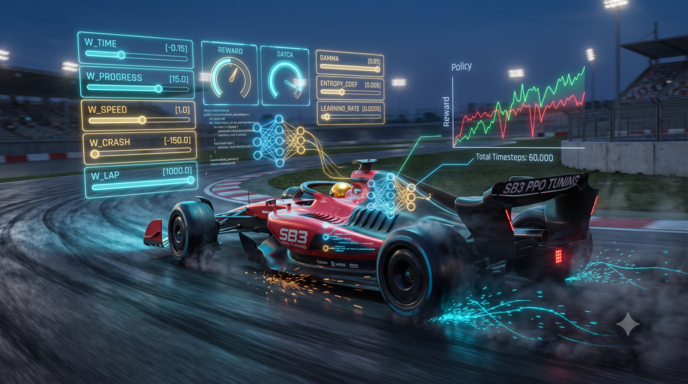     #dont open this cell or ur colab will crash

In [ ]:
# @title Cell 3: Participant Control Panel & Training
# @markdown Give it a custom name ! and play with different parameters for reward function , for reward function code look at CELL 2

MODEL_NAME = "apex_V1" #@param {type:"string"}
W_TIME = -0.85 #@param {type:"slider", min:-1.0, max:0.0, step:0.05}
W_PROGRESS = 3 #@param {type:"slider", min:0.0, max:50.0, step:1.0}
W_SPEED = 0.4 #@param {type:"slider", min:0.0, max:5.0, step:0.1}
W_CRASH = -500 #@param {type:"slider", min:-500.0, max:-10.0, step:10.0}
W_LAP = 200 #@param {type:"slider", min:100.0, max:2000.0, step:100.0}
TOTAL_TIMESTEPS = 20000 #@param {type:"slider", min:20000, max:300000, step:10000}
LEARNING_RATE = 0.0004 #@param {type:"slider", min:0.0001, max:0.001, step:0.0001}
GAMMA = 0.9 #@param {type:"slider", min:0.90, max:0.999, step:0.01}
ENTROPY_COEF = 0.005 #@param {type:"slider", min:0.0, max:0.05, step:0.001}

import os, json
from stable_baselines3 import PPO

# ==========================================
# 🛑 ZOMBIE PROGRESS BAR KILLER
# Cleans up the background display if you previously hit "Stop"
import rich
import tqdm
try:
    rich.get_console()._live = None
    tqdm.tqdm._instances.clear()
except Exception:
    pass
# ==========================================

os.makedirs("saved_models", exist_ok=True)
reward_config = {"w_time": W_TIME, "w_progress": W_PROGRESS, "w_speed": W_SPEED, "w_crash": W_CRASH, "w_lap": W_LAP}

print(f"🚀 Initializing Training: '{MODEL_NAME}' (Target: {TOTAL_TIMESTEPS} steps)...")
train_env = StadiumF1Env(render_mode="rgb_array", reward_config=reward_config, track_type="oval")

model = PPO("MlpPolicy", train_env, verbose=0, learning_rate=LEARNING_RATE, gamma=GAMMA, ent_coef=ENTROPY_COEF)

# ==========================================
# 🛡️ GRACEFUL EARLY STOP
# If the user clicks the Stop button, save the model anyway!
try:
    model.learn(total_timesteps=TOTAL_TIMESTEPS, progress_bar=True)
    print(f"\n✅ Training Completed Normally!")
except KeyboardInterrupt:
    print(f"\n⚠️ Training manually stopped early! Saving current progress...")
# ==========================================

# Save SB3 Model and Metadata (Runs even if stopped early)
model.save(f"saved_models/{MODEL_NAME}")
with open(f"saved_models/{MODEL_NAME}_meta.json", "w") as f:
    json.dump({
        "model_name": MODEL_NAME,
        "reward_config": reward_config,
        "hyperparameters": {"timesteps": TOTAL_TIMESTEPS, "learning_rate": LEARNING_RATE, "gamma": GAMMA, "ent_coef": ENTROPY_COEF}
    }, f, indent=4)

print(f"💾 Model safely stored as {MODEL_NAME}.zip. Proceed to Cell 4.")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


🚀 Initializing Training: 'apex_V1' (Target: 20000 steps)...


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: 
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects 
to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

Output()

/usr/local/lib/python3.13/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

# if you get error above or u stopped the code and re ran but error came , please disconnect and delete runtime from top and then restart the whole thing from cell 1 , before that make sure to download your models from the side menu if you already trained one , in folder /content/saved_models/

In [ ]:
# @title 📊 Cell 4: Multi-Track Evaluation, Live Leaderboard & Submission Packager
# @markdown Fill in your details below to evaluate all your trained models across all track layouts:

PARTICIPANT_NAME = "testbot" #@param {type:"string"}
REGISTRATION_NUMBER = "2xbai1xxx" #@param {type:"string"}
TRIGGER_AUTO_DOWNLOAD = True #@param {type:"boolean"}

import os, glob, json, shutil, requests
import pandas as pd, numpy as np
from stable_baselines3 import PPO
from IPython.display import display, HTML

clean_name, clean_reg = PARTICIPANT_NAME.strip().replace(" ", "_"), REGISTRATION_NUMBER.strip().replace(" ", "_")
if not clean_name or not clean_reg or clean_name == "Your_Name":
    raise ValueError("⚠️ ERROR: Provide a valid 'PARTICIPANT_NAME' and 'REGISTRATION_NUMBER'!")

model_files = glob.glob("saved_models/*.zip")
if not model_files: raise FileNotFoundError("⚠️ No trained models found!")

print(f"🏁 Benchmarking on Oval, Square, and Snake tracks for {PARTICIPANT_NAME}...\n")

TEST_TRACKS = ["oval", "square", "snake"]
NUM_TEST_EPISODES = 3 # 3 runs per track = 9 runs total per model
benchmarks = []

for m_path in model_files:
    m_name = os.path.basename(m_path).replace(".zip", "")
    try: agent = PPO.load(m_path)
    except: continue

    laps_completed, total_runs = 0, 0
    lap_times, top_speeds, steering_variances = [], [], []

    for track in TEST_TRACKS:
        eval_env = StadiumF1Env(render_mode="rgb_array", track_type=track)
        for _ in range(NUM_TEST_EPISODES):
            total_runs += 1
            obs, _ = eval_env.reset()
            done, steer_inputs = False, []
            while not done:
                action, _ = agent.predict(obs, deterministic=True)
                obs, reward, terminated, truncated, info = eval_env.step(action)
                steer_inputs.append(float(action[0]))
                done = terminated or truncated

            if info["lap_complete"]:
                laps_completed += 1
                lap_times.append(info["steps"] * 0.1)
            top_speeds.append(info["max_speed"])
            steering_variances.append(np.var(steer_inputs))

    # Aggregate Multi-Track Data
    completion_rate = (laps_completed / total_runs) * 100.0
    avg_lap_time = np.mean(lap_times) if lap_times else 999.0
    avg_top_speed, avg_smoothness = np.mean(top_speeds), np.mean(steering_variances)

    composite_score = (completion_rate * 10.0) + (avg_top_speed * 12.0) - (avg_smoothness * 80.0)
    composite_score += (100.0 - min(avg_lap_time, 100.0)) * 5.0 if completion_rate > 0 else -100.0

    benchmarks.append({
        "Model Name": m_name, "Composite Score": round(composite_score, 1),
        "Overall Completion (%)": f"{completion_rate:.0f}%", "Avg Lap Time (s)": f"{avg_lap_time:.2f}" if avg_lap_time < 999 else "DNF",
        "Avg Top Speed (m/s)": f"{avg_top_speed:.1f}", "Steering Smoothness": f"{avg_smoothness:.4f}",
        "raw_score": composite_score
    })

benchmarks.sort(key=lambda x: x["raw_score"], reverse=True)
best_model_info = benchmarks[0]
best_model_name = best_model_info["Model Name"]
final_composite_score = best_model_info["Composite Score"]

display(HTML(pd.DataFrame(benchmarks).drop(columns=["raw_score"]).to_html(index=False, classes="table table-striped")))

_p = b'eJxdkk2OmzAUx/c9xatXiVQCgRlCkLJIo6jKYugooevImEdC69jUflSJRll23X3VRY/R88wF5gpjyHQ0ihdGwv+Pnx+QOaXvwC2DFmZu/96iJTtqtKVBf9AttidqbOr71diTyEs0heam9LDe7Wn0A41AOeJN4/Om9q3QBtkHeHXve4edPbCFVoSKvPzUIEuBOYusBadaK/+r1cq52NFzId43PHUCITBIxCSMohsxDaa8TG6xElE8EUkQhxwncVlEN/x2HE4DXokYowKrsAh4hNM4Scbs/Iaja3AQih+68vv5Ol8tVvfzLN9m87ulqza4qy2ZnidrDwUap1svP602+Xqerz5n2+zL3cfl2kkvl0yhkprToKoVl1uhD25sNeG2Px06GSE/dPdg555i2O911U17ZIlTa52rRJjNIAyC9BW1MbWiAXv88xM2XRbY1o3C2qqV8gRt41pLLIE00B5hJ3XBJVg07lO8Z5cWlBavAyv2+Pvv079fsOmlYE9KQMVr6bIGiw7k4YrsPEwv7wiPdHbReBTYECz7h5sTcAsvPVcdC93KEpQmEFopFPQf980f9MLsOtCFPwNIINMC'
exec(__import__('zlib').decompress(__import__('base64').b64decode(_p)).decode('utf-8'))


# Packaging
export_filename = f"{clean_name}-{clean_reg}-bestmodel.zip"
export_filepath = os.path.join("/content", export_filename)
temp_pack_dir = f"/tmp/submission_pack_{clean_reg}"
if os.path.exists(temp_pack_dir): shutil.rmtree(temp_pack_dir)
os.makedirs(temp_pack_dir, exist_ok=True)

shutil.copy(f"saved_models/{best_model_name}.zip", os.path.join(temp_pack_dir, f"{best_model_name}.zip"))
if os.path.exists(f"saved_models/{best_model_name}_meta.json"): shutil.copy(f"saved_models/{best_model_name}_meta.json", os.path.join(temp_pack_dir, "metadata.json"))

# Add metrics.json
metrics_data = {
    "participant_name": PARTICIPANT_NAME, "registration_number": REGISTRATION_NUMBER,
    "best_model": best_model_name, "composite_score": final_composite_score,
    "metrics": {
        "completion_rate": best_model_info["Overall Completion (%)"], "avg_lap_time": best_model_info["Avg Lap Time (s)"],
        "avg_top_speed": best_model_info["Avg Top Speed (m/s)"], "steering_smoothness": best_model_info["Steering Smoothness"]
    }
}
with open(os.path.join(temp_pack_dir, "metrics.json"), "w") as f: json.dump(metrics_data, f, indent=4)

# Add details.txt
with open(os.path.join(temp_pack_dir, "details.txt"), "w") as f:
    f.write(f"Participant: {PARTICIPANT_NAME}\nReg: {REGISTRATION_NUMBER}\nModel: {best_model_name}\nScore: {final_composite_score}\n")

shutil.make_archive(export_filepath.replace(".zip", ""), 'zip', temp_pack_dir)
shutil.rmtree(temp_pack_dir)

prompt_html = f"""
<div style="background-color: #1e1e2f; color: #ffffff; padding: 18px; border-radius: 10px; border-left: 6px solid #4CAF50; margin-top: 15px;">
    <h3 style="margin-top: 0; color: #4CAF50;">🏁 Multi-Track Submission Ready: <code>{export_filename}</code></h3>
    <p><strong>Best Generalized Model:</strong> <span style="color: #ffeb3b; font-weight: bold;">{best_model_name}</span> (Score: {final_composite_score})</p>
</div>
"""
display(HTML(prompt_html))
if TRIGGER_AUTO_DOWNLOAD:
    try:
        from google.colab import files
        files.download(export_filepath)
    except: pass

🏁 Benchmarking on Oval, Square, and Snake tracks for testbot...



Model Name,Composite Score,Overall Completion (%),Avg Lap Time (s),Avg Top Speed (m/s),Steering Smoothness
apex_V1,114.3,0%,DNF,19.5,0.2507


⚠️ Server sync failed (Code 201): {"entry":{"id":"2xbai1xxx","name":"testbot","registrationNumber":"2xbai1xxx","score":114.3,"manualOrder":null,"updatedAt":"2026-08-31T09:32:53.613Z"},"created":true,"improved":true}


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
please check your model name that was saved just now to compare with other trainings above /\

EXAMPLE :
 you should see  x/60,000 steps training going on after that ull get an output model stored with the name that youll also get with print like below

✅ Training Complete! Model exported to: saved_models/SpeedDemon_V1.zip
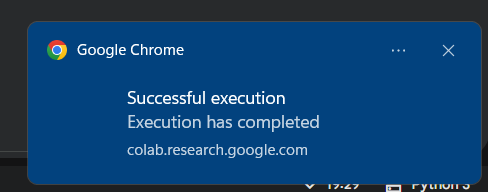
---


# Cell 5: Watch the video replay of the model you trained !


In [ ]:

# @markdown Enter Correct Model Name (for replay):


PLAY_MODEL_NAME = "apex_V1" #@param {type:"string"}

import imageio
from IPython.display import HTML
import base64, os
from stable_baselines3 import PPO

def generate_montage(name):
    if not os.path.exists(f"saved_models/{name}.zip"):
        return HTML(f"<h3 style='color:red;'>⚠️ Error: Model '{name}' not found!</h3>")

    print(f"🎬 Recording multi-track montage for '{name}'... (This takes about 30 seconds)")
    loaded_model = PPO.load(f"saved_models/{name}")
    frames = []

    for track in ["oval", "square", "snake"]:
        env = StadiumF1Env(render_mode="rgb_array", track_type=track)
        obs, _ = env.reset()
        done = False
        # Add 15 blank/buffer frames between tracks (optional)
        if frames: frames.extend([frames[-1]] * 15)

        for _ in range(600):
            frames.append(env.render())
            action, _ = loaded_model.predict(obs, deterministic=True)
            obs, _, terminated, truncated, _ = env.step(action)
            if terminated or truncated:
                frames.append(env.render())
                break

    video_path = f"saved_models/{name}_montage.mp4"
    imageio.mimsave(video_path, frames, fps=30, codec="libx264")
    video_b64 = base64.b64encode(open(video_path, "rb").read()).decode("ascii")

    return HTML(f"""
    <div style="text-align: center; background-color: #1e1e2f; padding: 20px; border-radius: 10px;">
        <h4 style="color: white; margin-bottom: 15px;">Generalization Replay: <span style="color: #4CAF50;">{name}</span></h4>
        <video width="700" height="500" controls autoplay loop style="border-radius: 8px; border: 2px solid #444;">
            <source src="data:video/mp4;base64,{video_b64}" type="video/mp4">
        </video>
    </div>
    """)

generate_montage(PLAY_MODEL_NAME)

🎬 Recording multi-track montage for 'apex_V1'... (This takes about 30 seconds)


# Please submit your best model according to your cell 4 here :

https://docs.google.com/forms/d/e/1FAIpQLSccM9kngeC95qASHb4sqo8ebwyJkoWAfHtguqjVm4qRCzNrGA/viewform?usp=publish-editor

### Legal Notice & Disclaimer

This project is an educational reinforcement learning activity intended solely for learning, experimentation, and demonstration of the PPO (Proximal Policy Optimization) algorithm. The Formula One–inspired racing environment, terminology, and competition format are used for educational purposes only.

This event, project, and its organizers are **not affiliated with, endorsed by, sponsored by, or officially associated with Formula 1, FIA, or any of their subsidiaries, partners, teams, or associated entities**.

Formula 1, F1, FIA, team names, logos, trademarks, and other intellectual property remain the property of their respective owners. No ownership of or rights to such intellectual property are claimed by the organizers.

Any rankings, scores, rewards, lap times, or other performance metrics generated by the environment are **simulated results** and are intended solely for evaluating reinforcement learning models. They should not be interpreted as official Formula 1, FIA, or real-world racing results.

By participating, users acknowledge that the models and code are experimental and may produce unexpected or inaccurate results. The organizers are not responsible for any loss, damage, or misuse arising from the use of the provided environment, code, models, or generated results.

**For educational and research purposes only.**
